In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import scipy.io as io
import argparse

import src.models.models as models
import src.training.self_supervision as ssl
import src.utils.utils as utils
import src.utils.extractor as extractor

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may hav

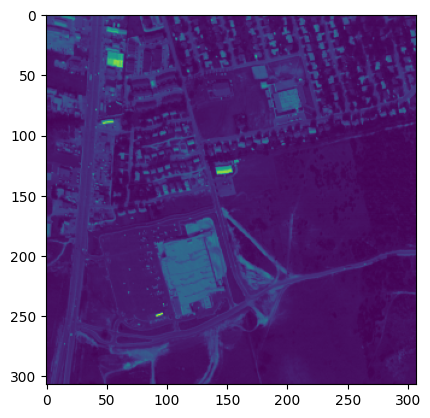

In [2]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)
E = torch.tensor(data["E"])
B, c, N = E.shape[0], E.shape[1], Y.shape[1]

Y = Y.reshape(Y.shape[0], int(Y.shape[1]**0.5), int(Y.shape[1]**0.5))
H, W = Y.shape[1], Y.shape[2]

patch_size = 5
batch_size=15

plt.imshow(Y.cpu()[10,:,:])

In [3]:
# dataset_full = utils.HSI_dataset(dataset=dataset)
# dataset_patched = utils.HSI_dataset(dataset=dataset, patch_size=patch_size)
# full_loader = DataLoader(dataset_full)
# patched_loader = DataLoader(dataset_patched)

full_loader, _, _ = utils.create_dataloader(dataset, dev, batch_size=batch_size)
patched_loader, test_loader, B, _ = utils.create_dataloader(dataset, dev, 0.7, patch_size, batch_size=batch_size)

## Models

In [4]:
"""
MLP: Adam "poly" learning rate policy lr=0.1 * (1-iter/max_iter)**0.99, rate_dropout=0.9
"""
mlpae = models.MLP_AE(B=B, c=c)
print("MLP: ", sum(p.numel() for p in mlpae.parameters() if p.requires_grad)/1e6, "M")

"""
CNN + linear decoder
"""
cnnlinear = models.CNNAE_linear(B=B, c=c, patch_size=patch_size)
print("CNN + linear decoder: ", sum(p.numel() for p in cnnlinear.parameters() if p.requires_grad)/1e6, "M")

"""
CNNAEU: epochs=320, lr=0.0003, batch=15
"""
Y_init, e_gt, a_gt = next(iter(full_loader))[0][0], next(iter(full_loader))[1][0], next(iter(full_loader))[2][0]
cnnaeu = models.CNNAEU(B=B, c =c)
cnnaeu = models.init_decoder_weights(cnnaeu, Y_init, c, 11)
print("CNNAEU: ", sum(p.numel() for p in cnnaeu.parameters() if p.requires_grad)/1e6, "M")

"""
Deep Trans: patch_size=5, a*L_RE + b*L_SAD (a ≃ 1e5*b), epochs=200, lr=6-9e-3 -20% every 15epochs, 
weight decay rate 4e-5 (inside adamw)
"""
Y_trans = Y[:,:(Y.shape[1]//patch_size)*patch_size,:(Y.shape[1]//patch_size)*patch_size]
deep_trans = models.Transformer_AE(B=B, c=c, im_size=Y_trans.shape[1], dim=200)
deep_trans = models.init_decoder_weights(deep_trans, Y_init, c)
print("Deep trans: ", sum(p.numel() for p in deep_trans.parameters() if p.requires_grad)/1e6, "M")

"""
NALMU
"""
nalmu_full = models.NALMU(B=B, c=c, N=N)
nalmu_patched = models.NALMU(B=B, c=c, N=patch_size**2)
print("NALMU: ", sum(p.numel() for p in nalmu_full.parameters() if p.requires_grad)/1e6, "M")

"""
RALMU
"""
ralmu_full = models.RALMU(B=B, c=c, im_size=H)
ralmu_patched = models.RALMU(B=B, c=c, im_size=patch_size)
print("RALMU: ", sum(p.numel() for p in ralmu_full.parameters() if p.requires_grad)/1e6, "M")

MLP:  0.160044 M
CNN + linear decoder:  0.150642 M
CNNAEU:  0.187992 M
Deep trans:  34.798871 M
NALMU:  5.66466 M
RALMU:  2.27417 M


## SSL methods

In [5]:
model = cnnaeu
epochs = 200
lr = 0.003

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = utils.PolyLR(optimizer, max_iter=epochs, power=0.99)

### Reconstruction error

torch.Size([162, 6]) torch.Size([1, 6, 94249])


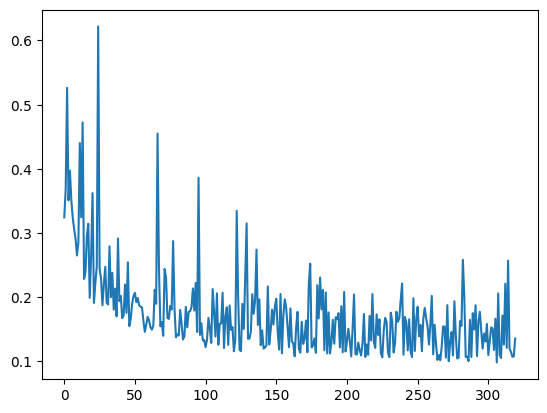

In [19]:
# re_trainer = ssl.ReconstructionError(model, patch_size=patch_size, epochs=epochs, lr=lr)
re_trainer = ssl.ReconstructionError(model, epochs=epochs, lr=lr)
e_hat_re, a_hat_re, train_losses_re = re_trainer.train(full_loader)
print(e_hat_re.shape, a_hat_re.shape)

plt.plot(train_losses_re)

### DIP

In [32]:
# dip_trainer = ssl.DIP(model, epochs=epochs, lr=lr)
# e_hat_dip, a_hat_dip, train_losses_dip = dip_trainer.train(full_loader)
# print(e_hat_dip.shape, a_hat_dip.shape)

# plt.plot(train_losses_dip)

### Two stages net

In [33]:
# two_s_trainer = ssl.TwoStagesNet(model, B, epochs=epochs, lr=lr)
# e_hat_twos, a_hat_twos, train_losses_twos = two_s_trainer.train(full_loader)
# print(e_hat_twos.shape, a_hat_twos.shape)

# plt.plot(train_losses_twos)

### Testing learned model:

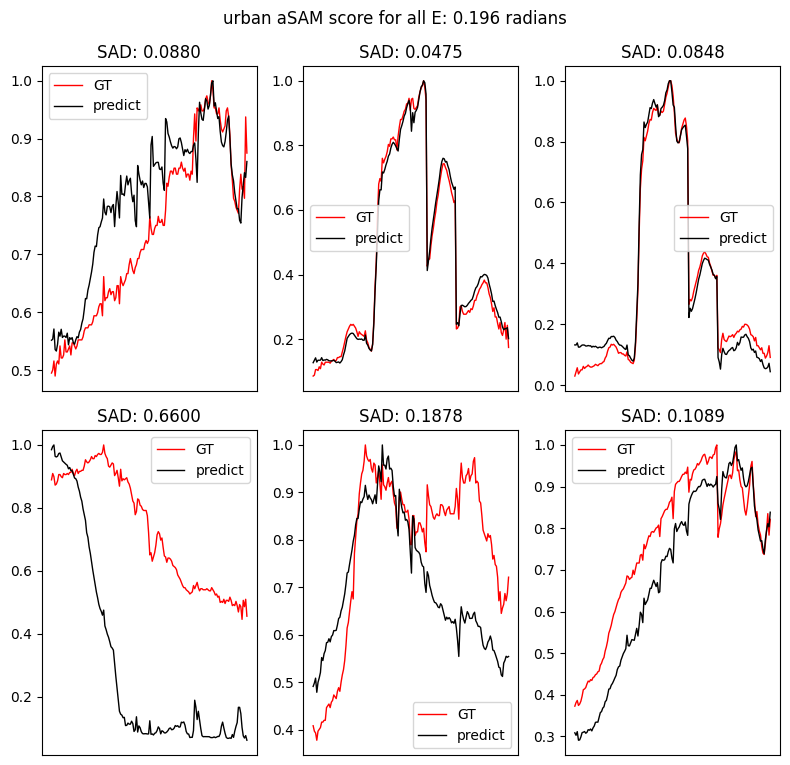

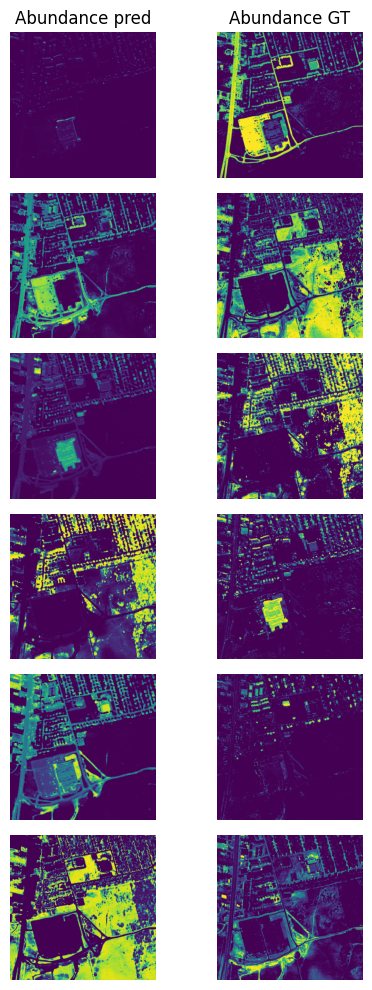

(array([0.08071658, 0.02714767, 0.01091953, 0.03850318, 0.02317367,
        0.06211886, 0.04042992], dtype=float32),
 array([0.08798272, 0.04751602, 0.08481078, 0.65996599, 0.18783322,
        0.10890768, 0.19616919]))

In [21]:
model.load_state_dict(torch.load(f"models/{model.__class__.__name__}_RE_{dataset}_lr_{lr}.pt")["model_state_dict"], strict=False)

# Y = torch.tensor(data["Y"])
# Y = Y.to(torch.float32)[:, :patch_size**2]

Y, e_gt, a_gt = next(iter(full_loader))[0][0], next(iter(full_loader))[1][0], next(iter(full_loader))[2][0]
# A_hat = []
# Y = Y_init.reshape(Y_init.shape[0], int(Y_init.shape[1]**0.5), int(Y_init.shape[1]**0.5))
# Y = Y[:, :(Y.shape[1]//patch_size)*patch_size, :(Y.shape[1]//patch_size)*patch_size]
# Y = Y.reshape(Y.shape[0], Y.shape[2]**2)

# a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))
# a_gt = a_gt[:,:(a_gt.shape[1]//patch_size)*patch_size,:(a_gt.shape[1]//patch_size)*patch_size]
# a_gt = a_gt.reshape(a_gt.shape[0], a_gt.shape[1]**2)

e_hat, a_hat, y_hat = model.forward(Y)
# e_hat = extractor.normalize_endmembers(e_hat)

# if e_hat.dim() == 3:
#     e_hat = e_hat.squeeze(0)

a_hat = a_hat.reshape(a_hat.shape[1], int(a_hat.shape[2]**0.5), int(a_hat.shape[2]**0.5))
a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))
# print(a_hat.shape)
# plt.imshow(a_gt[0,:,:].detach().cpu())

utils.compute_metrics_and_plot(e_hat, e_gt, a_hat, a_gt, dataset)
# A_hat = torch.cat(A_hat, dim=1)

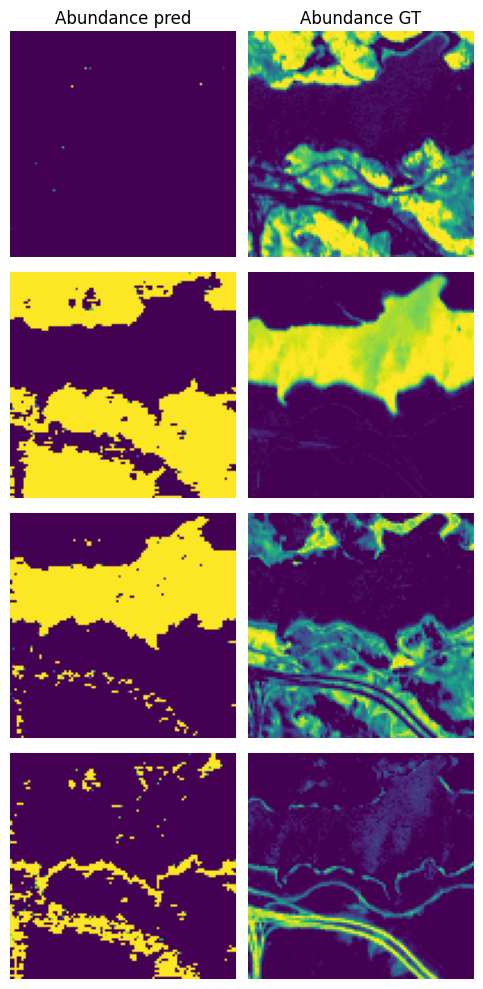

In [ ]:
# fig, axes = plt.subplots(a_hat.shape[0], 2, figsize=(5, 10))
# axes[0, 0].set_title("Abundance pred", fontsize=12)
# axes[0, 1].set_title("Abundance GT", fontsize=12)

# # Plot tensor images
# for i in range(a_hat.shape[0]):
#     axes[i, 0].imshow(a_hat[i].detach().cpu())
#     axes[i, 0].axis('off')

#     axes[i, 1].imshow(a_gt[i].detach().cpu())
#     axes[i, 1].axis('off')

# # Adjust layout to reduce white space
# plt.subplots_adjust(wspace=0.05, hspace=0.1)
# plt.tight_layout()
# plt.show()